In [64]:
import numpy as np
def initialize_centroids(X,K):
    indices = np.random.choice(X.shape[0],K,replace = False)
    return X[indices]

def compute_distances(X,centroids):
    X = X[:,np.newaxis,:]
    centroids = centroids[np.newaxis]

    difference = X-centroids
    squared_difference = difference**2
    distance = np.sum(squared_difference,axis = 2)
    return distance

def assign_clusters(distances):
    return np.argmin(distances, axis = 1)

def update_centroids(X,assignments,K):
    updated_centroids = []
    for k in range(K):
        cluster_k_data = X[assignments==k]
        if cluster_k_data.shape[0] == 0:
            updated_centroids.append(X[np.random.choice(X.shape[0])])
        else:
            centroid = np.mean(cluster_k_data,axis= 0)
            updated_centroids.append(centroid)
        
    return np.array(updated_centroids)

def run_kmeans(X,K,max_iters = 100):
    centroids = initialize_centroids(X,K)

    for iter in range(max_iters):
        print(centroids)
        old_centroids = centroids.copy()
        distances = compute_distances(X,centroids)
        assignments = assign_clusters(distances)

        centroids = update_centroids(X,assignments,K)

        if(np.all(old_centroids==centroids)):
            break

    return centroids,assignments

[[ 5.83033582 -5.85608383]
 [ 3.81674149 -7.03923218]
 [ 4.00946367  4.43370227]]
[[ 5.29063253 -4.96427712]
 [-3.30465497 -5.12328611]
 [ 4.79166953  4.97282143]]
[[ 4.95496261 -5.12627268]
 [-4.87175128 -4.95651235]
 [ 4.88443575  5.03402232]]
Final Centroid Shapes: (3, 2)
Assignments Shape: (300,)


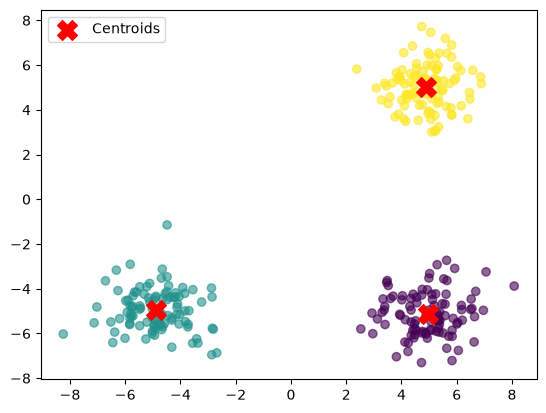

In [65]:
import matplotlib.pyplot as plt

# --- 1. Generate Synthetic Data (N=300, D=2, K=3) ---
np.random.seed(42)
cluster_1 = np.random.randn(100, 2) + np.array([5, 5])
cluster_2 = np.random.randn(100, 2) + np.array([-5, -5])
cluster_3 = np.random.randn(100, 2) + np.array([5, -5])
X_test = np.vstack([cluster_1, cluster_2, cluster_3]) # Shape: (300, 2)

# --- 2. Run YOUR Code ---
np.random.seed(None)
centroids, assignments = run_kmeans(X_test, K=3, max_iters=1000)

# --- 3. Sanity Check Output ---
print("Final Centroid Shapes:", centroids.shape) # Should be (3, 2)
print("Assignments Shape:", assignments.shape)   # Should be (300,)

# --- 4. Plot the results ---
plt.scatter(X_test[:, 0], X_test[:, 1], c=assignments, cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.legend()
plt.show()

In [67]:
from sklearn.cluster import KMeans

# 1. Initialize the model
# K is called 'n_clusters'
# Scikit-Learn handles the multiple restarts we discussed using 'n_init'
# It uses the smarter 'k-means++' initialization by default instead of random points
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100, random_state=42)

# 2. Fit the model and get assignments
# This does the exact same distance calculation and centroid updating you wrote
assignments = kmeans.fit_predict(X_test)  # Shape: (N,)

# 3. Retrieve the centroids
centroids = kmeans.cluster_centers_       # Shape: (K, D)

# 4. Retrieve the Inertia (J)
inertia = kmeans.inertia_                 # Scalar
print(centroids)

[[-4.87175128 -4.95651235]
 [ 4.88443575  5.03402232]
 [ 4.95496261 -5.12627268]]
